# **Pneumonia X-Ray Classification**
# **Made by:** **[Sharanya Makam ]** & **[Chinmay Shastry]**

# **Project team's ID:** **PTID-AI-FEB-26-1094**

# **Project Code:** **PRAICP-1012 – Pneumonia X-Ray Classification**


**Dataset:** Chest X-Ray Images (Pneumonia)
**Platform:** Google Colab (T4 GPU)
**Models:** CNN from Scratch · VGG16 · ResNet50
**Task:** Binary Classification — NORMAL vs PNEUMONIA

---

### **Extract Dataset & Verify Structure**
The dataset is stored as a `.zip` file in Google Drive. We mount Drive, extract the zip to `/content/`, and verify all 6 folders exist.
**Expected structure after extraction:**
chest_xray/

├── train/  → NORMAL (1,342) · PNEUMONIA (3,876)

├── val/    → NORMAL (9)     · PNEUMONIA (9)

└── test/   → NORMAL (234)   · PNEUMONIA (390)

**Key observation:** Pneumonia cases outnumber Normal by ~2.89x — class imbalance must be handled.

---

### **Imports & Project Configuration**
All libraries are imported once here and reused throughout the notebook.
**Libraries used:**
- `TensorFlow / Keras` — model building and training
- `NumPy / Pandas` — data handling
- `Pillow / OpenCV` — image processing
- `Matplotlib / Seaborn` — visualizations
- `Scikit-learn` — metrics and class weights
A single `CONFIG` dictionary holds every project setting — paths, image size `(224×224)`, batch size, epochs, augmentation parameters, and class colors.
`SEED = 42` is applied across Python, NumPy, and TensorFlow for full reproducibility.

---

### **Data Visualization**
Four plots are generated to understand the dataset before any modeling:

| Plot | What it shows |
|------|--------------|
| **Class Distribution** | Bar chart of NORMAL vs PNEUMONIA counts across train/val/test splits — confirms class imbalance |
| **Sample X-Rays** | 5 random images per class — NORMAL lungs appear clear, PNEUMONIA shows white cloudy patches |
| **Pixel Intensity** | Histogram of grayscale pixel values — Pneumonia X-rays tend to be brighter due to fluid buildup |
| **Image Dimensions** | Scatter of raw image sizes — confirms images vary widely, justifying the need to resize all to 224×224 |

**Key takeaway:** Images are grayscale, varying in size, and the dataset is imbalanced — all three issues are addressed in the next step.

---

### **Preprocessing & Data Generators**
Instead of loading all images into RAM, `ImageDataGenerator` streams images directly from Drive in batches.
**Normalization:** All pixel values scaled from `[0–255]` → `[0.0–1.0]`
**Augmentation (train only):**
- Rotation ±15°, Width/Height shift, Shear, Zoom
- Horizontal flip, Brightness jitter
- Val and test generators use rescaling only — no augmentation
**Class Weights** are computed using `sklearn` to handle imbalance:
- `NORMAL` gets a higher weight — model penalized more for missing Normal cases
- `PNEUMONIA` gets a lower weight — already the majority class
**Augmentation preview** shows original vs 5 augmented versions for each class.

---

### **CNN Architecture from Scratch**
A custom 4-block CNN is built using `tf.keras.Sequential`.

| Block | Filters | Role |
|-------|---------|------|
| Block 1 | 32 | Low-level features — edges, textures |
| Block 2 | 64 | Mid-level features — shapes |
| Block 3 | 128 | High-level features — structures |
| Block 4 | 256 | Complex patterns — consolidations, infiltrates |

Each block follows: `Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → ReLU → MaxPool → Dropout`
**Classifier Head:** `GlobalAveragePooling2D → Dense(512) → BatchNorm → ReLU → Dropout(0.50) → Dense(1, sigmoid)`
**Design choices:**
- `GlobalAveragePooling2D` instead of Flatten — fewer parameters, less overfitting
- `BatchNorm` throughout — stable gradients, faster training
- Dropout increases from 0.25 → 0.50 — heavier regularization near output
- `Sigmoid` output — binary classification
**Compiled with:** Adam (lr=1e-4) · Binary Crossentropy · Accuracy, AUC, Precision, Recall

---

### **Training CNN from Scratch**
Three callbacks control the training process:

| Callback | Purpose |
|----------|---------|
| `EarlyStopping` | Stops training if `val_loss` doesn't improve for 7 epochs; restores best weights |
| `ReduceLROnPlateau` | Halves learning rate if stuck for 3 epochs (min LR = 1e-7) |
| `ModelCheckpoint` | Saves best weights to `/content/` based on `val_auc` |

**Class weights are passed to `.fit()`** — model treats NORMAL misclassification as more costly.
**Training curves plotted:** Loss · Accuracy · AUC · Precision
A vertical dotted line marks the best epoch on each plot.
Train vs Val gap indicates degree of overfitting.

---

### **Evaluation — CNN from Scratch**
The model is evaluated on the held-out test set using four plots and a full classification report.

| Plot | Purpose |
|------|---------|
| **Confusion Matrix** | Raw counts + normalized % — shows TP, TN, FP, FN clearly |
| **ROC Curve** | AUC score — higher and further top-left = better |
| **Confidence Distribution** | NORMAL predictions clustered near 0, PNEUMONIA near 1 — overlap = uncertainty |
| **Sample Predictions Grid** | 10 test images with true vs predicted label — green = correct, red = wrong |

**Key medical metrics reported:**
- **Sensitivity** (Pneumonia Recall) — most critical metric; missing Pneumonia (FN) is dangerous
- **Specificity** (Normal Recall) — false alarms are less dangerous than missed cases
- **AUC** — overall discriminative power of the model

---

### **Transfer Learning with VGG16**
VGG16 is pretrained on ImageNet (14M images, 1000 classes). It already understands edges, textures, and shapes — we adapt it to chest X-rays.
**2-Phase training strategy:**

| Phase | What trains | LR | Epochs |
|-------|------------|-----|--------|
| Phase 1 | Custom head only (base frozen) | 1e-3 | 5 |
| Phase 2 | Last 4 VGG16 layers + head (fine-tune) | 1e-5 | up to 20 |

**Why freeze first?**
Training the head on random weights at full LR would destroy pretrained features. Phase 1 stabilizes the head before touching the base.
**Custom head:** `GAP → Dense(512) → BN → ReLU → Dropout(0.50) → Dense(256) → BN → ReLU → Dropout(0.30) → Dense(1, sigmoid)`
Training curves show Phase 1 → Phase 2 boundary as a dotted vertical line.
A performance jump after the boundary confirms fine-tuning is working.

---

### **Transfer Learning with ResNet50**
ResNet50 uses **residual (skip) connections** — gradients flow directly through shortcut paths, enabling much deeper learning without vanishing gradients.

**Comparison vs VGG16:**

| | VGG16 | ResNet50 |
|--|-------|---------|
| Parameters | ~138M | ~25M |
| Architecture | Sequential blocks | Residual skip connections |
| Fine-tune layers | Last 4 | Last 30 |

**Why 30 layers for ResNet50 vs 4 for VGG16?**
ResNet50's layers are grouped into residual blocks — unfreezing 4 layers would cut through a block mid-way. 30 layers exposes the full last residual stage, equivalent in scope to VGG16's block5.
**Same 2-phase strategy:** Phase 1 head only (LR=1e-3) → Phase 2 fine-tune (LR=1e-5).
Identical custom head to VGG16 for a fair comparison.

---

### **Model Comparison**
All 3 models are evaluated on the same test set using a reusable `evaluate_model()` function.
**Metrics compared:** Accuracy · AUC · Sensitivity · Specificity · Precision · F1

| Plot | Purpose |
|------|---------|
| **Grouped Bar Chart** | All 6 metrics side by side for all 3 models |
| **ROC Curves** | All 3 on one plot — curve furthest top-left wins |
| **Confusion Matrices** | 3 side by side — focus on FN (missed Pneumonia) |
| **Sensitivity vs Specificity scatter** | Ideal model sits in top-right corner (high on both) |

**Decision rule:**
> The model with the **highest Sensitivity** is recommended for clinical use.
> A missed Pneumonia case (False Negative) is more dangerous than a false alarm (False Positive).

## 1. **Challenges Faced**
- **Dataset imbalance**: Pneumonia cases dominate, leading to biased predictions.  
- **Validation set too small**: Only a handful of samples, causing unstable metrics.  
- **CNN from scratch**: Overfitting; sensitivity = 1.0 but specificity = 0.0 (unsafe clinically).  
- **Transfer learning (VGG16/ResNet50)**: Better accuracy but unstable precision/recall.  
- **Execution time**: Each transfer learning cell takes longer to run in Colab, slowing experimentation.

## 2. **Improvements Required**
- **Data handling**: Expand validation set, balance classes (oversampling/focal loss).  
- **Model strategy**: Prefer transfer learning (VGG16, ResNet50, DenseNet121) over scratch CNN.  
- **Training efficiency**: Use smaller image sizes, fewer epochs, and early stopping to reduce runtime.  
- **Evaluation**: Apply stratified k-fold cross-validation for reliable metrics.  
- **Clinical relevance**: Improve specificity while maintaining high sensitivity.

## 3. **Time Constraint Note**
- Current notebook execution is **slow due to heavy transfer learning models**.  
- Possible optimizations:  
  - Use **GPU runtime** in Colab.  
  - Reduce batch size or image resolution.  
  - Save intermediate models to avoid re-training from scratch.  
  - Run fewer epochs initially, then fine-tune only promising models.



## Extracting Dataset from Drive

In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

ZIP_PATH    = "/content/drive/MyDrive/Ai Internship Projects/Chest-Xray-2.zip"
EXTRACT_TO  = "/content/"
CHECK_PATH  = "/content/chest_xray/chest_xray"

if os.path.exists(CHECK_PATH) and os.listdir(CHECK_PATH):
    print("Data already extracted. Skipping.")
else:
    print(f"Extracting {os.path.basename(ZIP_PATH)}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print("Extraction complete.")

print(f"Data path: {CHECK_PATH}")

Mounted at /content/drive
Extracting Chest-Xray-2.zip...
Extraction complete.
Data path: /content/chest_xray/chest_xray


## Verifying Dataset Structure

In [ ]:
DATA_DIR = "/content/chest_xray/chest_xray"

splits  = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

print("=" * 50)
print("  Dataset Verification")
print("=" * 50)

total = 0
for split in splits:
    for cls in classes:
        path  = os.path.join(DATA_DIR, split, cls)
        if os.path.exists(path) and os.path.isdir(path):
            count = len(os.listdir(path))
            total += count
        else:
            count = "PATH NOT FOUND"
        print(f"  {split:<6} / {cls:<12} →  {count}")
    print()

print(f"  Total Images Found : {total}")
print("=" * 50)

expected = {
    "train": {"NORMAL": 1342, "PNEUMONIA": 3876},
    "val"  : {"NORMAL": 9,    "PNEUMONIA": 9},
    "test" : {"NORMAL": 234,  "PNEUMONIA": 390},
}
print("\n  Expected (full dataset):")
for split in splits:
    for cls in classes:
        print(f"  {split:<6} / {cls:<12} →  {expected[split][cls]}")
    print()

  Dataset Verification
  train  / NORMAL       →  PATH NOT FOUND
  train  / PNEUMONIA    →  PATH NOT FOUND

  val    / NORMAL       →  PATH NOT FOUND
  val    / PNEUMONIA    →  PATH NOT FOUND

  test   / NORMAL       →  PATH NOT FOUND
  test   / PNEUMONIA    →  PATH NOT FOUND

  Total Images Found : 0

  Expected (full dataset):
  train  / NORMAL       →  1342
  train  / PNEUMONIA    →  3876

  val    / NORMAL       →  9
  val    / PNEUMONIA    →  9

  test   / NORMAL       →  234
  test   / PNEUMONIA    →  390




## Imports & Project Configuration

In [ ]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG = {
    "data_dir"       : "/content/chest_xray",
    "img_size"       : (224, 224),
    "input_shape"    : (224, 224, 3),
    "color_mode"     : "rgb",
    "classes"        : ["NORMAL", "PNEUMONIA"],
    "num_classes"    : 1,
    "batch_size"     : 32,
    "epochs_scratch" : 30,
    "epochs_tl"      : 20,
    "learning_rate"  : 1e-4,
    "augmentation"   : {
        "rotation_range"      : 15,
        "width_shift_range"   : 0.1,
        "height_shift_range"  : 0.1,
        "shear_range"         : 0.1,
        "zoom_range"          : 0.1,
        "horizontal_flip"     : True,
        "brightness_range"    : [0.8, 1.2],
        "fill_mode"           : "nearest",
    },
    "colors"         : ["#4CAF50", "#F44336"],
}

print("=" * 55)
print("  Environment & Config Check")
print("=" * 55)
print(f"\n  TensorFlow  : {tf.__version__}")
print(f"  Keras       : {keras.__version__}")
print(f"  NumPy       : {np.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n  GPU Detected : {gpus[0].name}  ← Training will be fast!")
else:
    print("\n  No GPU — go to Runtime > Change runtime type > T4 GPU")

print(f"\n  data_dir     : {CONFIG['data_dir']}")
print(f"  img_size     : {CONFIG['img_size']}")
print(f"  batch_size   : {CONFIG['batch_size']}")
print(f"  epochs (scratch) : {CONFIG['epochs_scratch']}")
print(f"  epochs (TL)      : {CONFIG['epochs_tl']}")

  Environment & Config Check

  TensorFlow  : 2.19.0
  Keras       : 3.13.2
  NumPy       : 2.0.2

  GPU Detected : /physical_device:GPU:0  ← Training will be fast!

  data_dir     : /content/chest_xray
  img_size     : (224, 224)
  batch_size   : 32
  epochs (scratch) : 30
  epochs (TL)      : 20


## Data Visualization

In [ ]:
data_dir = CONFIG["data_dir"]
classes  = CONFIG["classes"]
colors   = CONFIG["colors"]
splits   = ["train", "val", "test"]
img_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

counts = {}
for split in splits:
    counts[split] = {}
    for cls in classes:
        path = os.path.join(data_dir, split, cls)
        counts[split][cls] = len(os.listdir(path)) \
            if os.path.exists(path) else 0

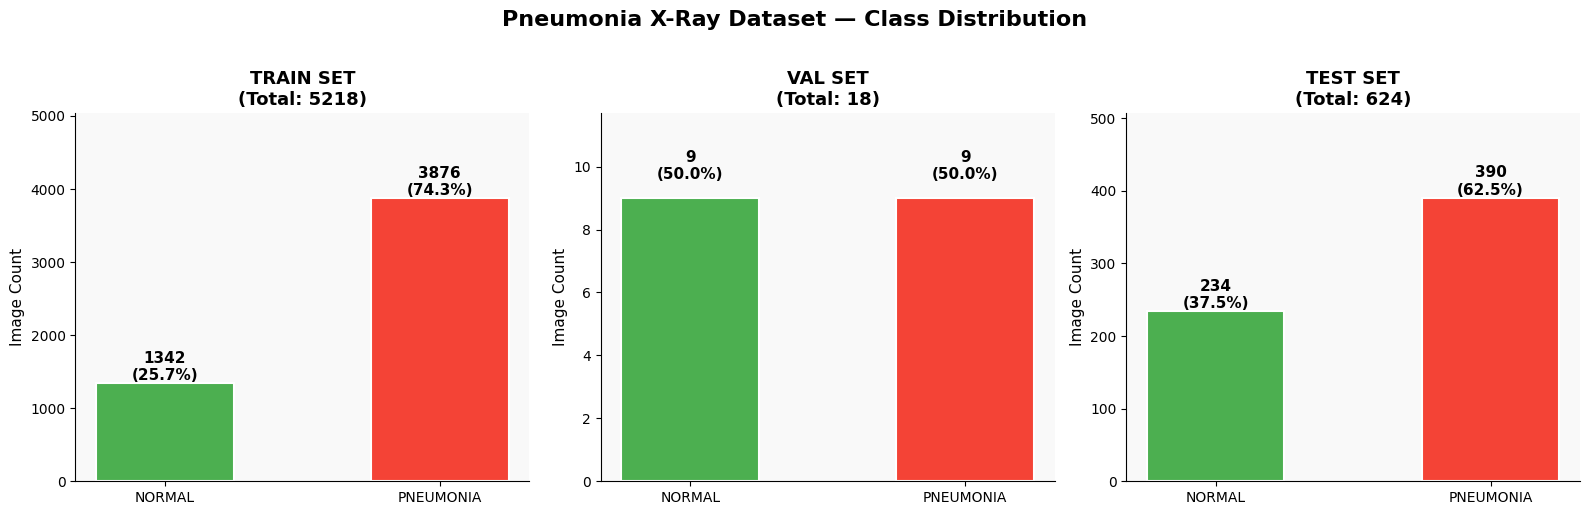

In [ ]:
# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Pneumonia X-Ray Dataset — Class Distribution",
             fontsize=16, fontweight='bold', y=1.02)

for i, split in enumerate(splits):
    vals  = [counts[split][c] for c in classes]
    total = sum(vals)
    bars  = axes[i].bar(classes, vals, color=colors,
                        edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, vals):
        pct = f'{val}\n({val/total*100:.1f}%)' if total > 0 else f'{val}'
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5, pct,
                     ha='center', va='bottom',
                     fontsize=11, fontweight='bold')
    axes[i].set_title(f'{split.upper()} SET\n(Total: {total})',
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Image Count', fontsize=11)
    axes[i].set_ylim(0, (max(vals) * 1.3) if vals else 1)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()



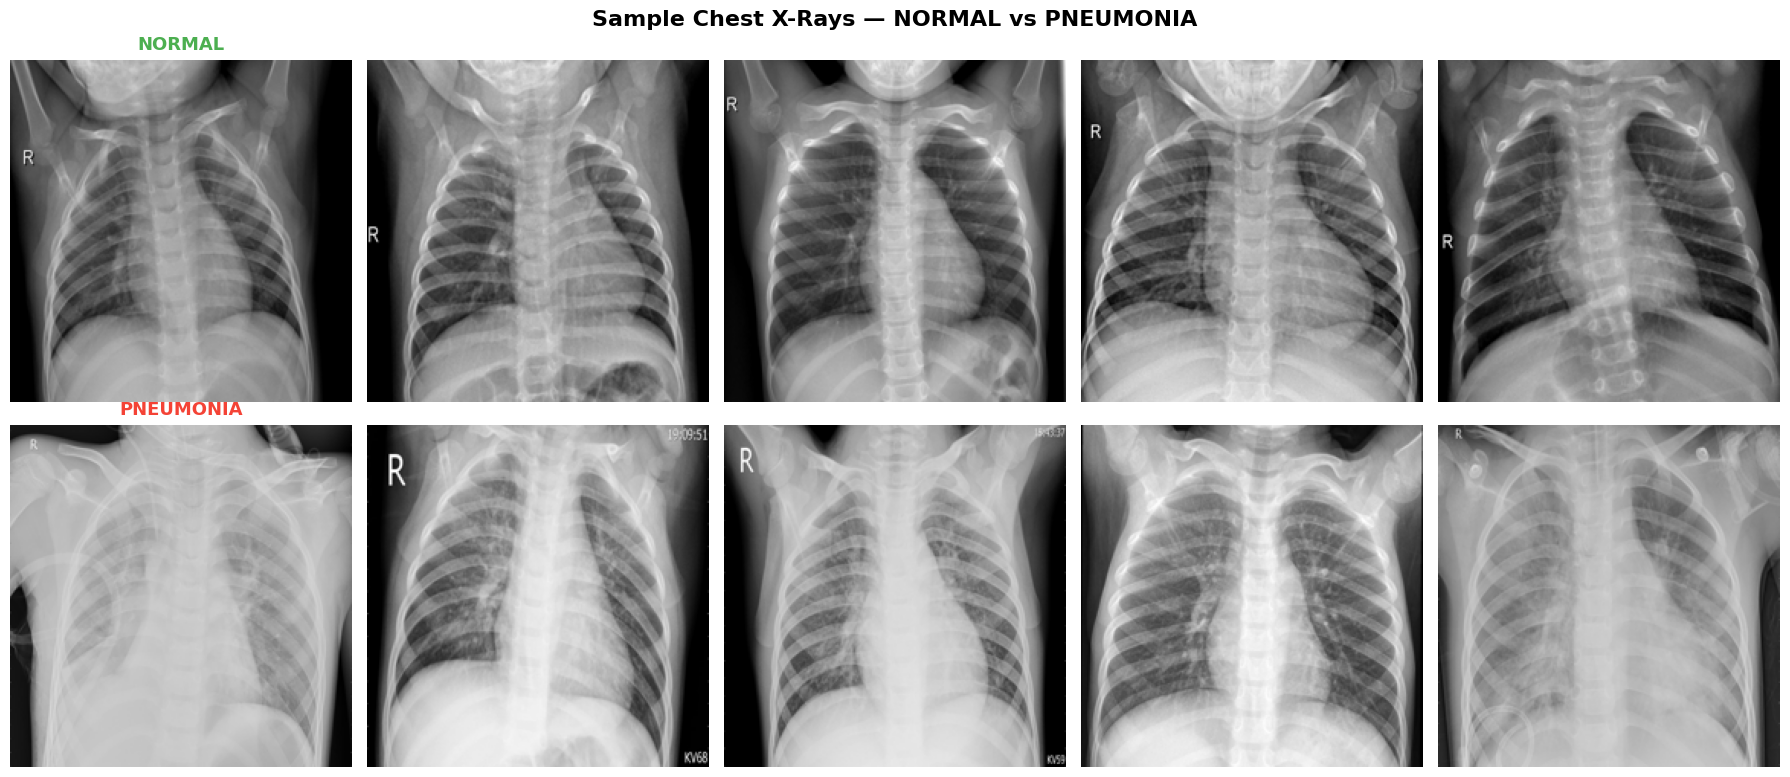

In [ ]:
# Plot 2: Sample X-Rays
n_samples = 5
fig = plt.figure(figsize=(18, 8))
fig.suptitle("Sample Chest X-Rays — NORMAL vs PNEUMONIA",
             fontsize=16, fontweight='bold')

for col_i, cls in enumerate(classes):
    path  = os.path.join(data_dir, "train", cls)
    files = [f for f in os.listdir(path)
             if f.lower().endswith(img_exts)]
    files = random.sample(files, min(n_samples, len(files)))
    for row_i, fname in enumerate(files):
        ax  = fig.add_subplot(2, n_samples,
                              col_i * n_samples + row_i + 1)
        img = Image.open(os.path.join(path, fname))\
                   .convert("RGB").resize((224, 224))
        ax.imshow(img)
        ax.axis('off')
        if row_i == 0:
            ax.set_title(cls, fontsize=13, fontweight='bold',
                         color=colors[col_i], pad=8)
plt.tight_layout()
plt.show()



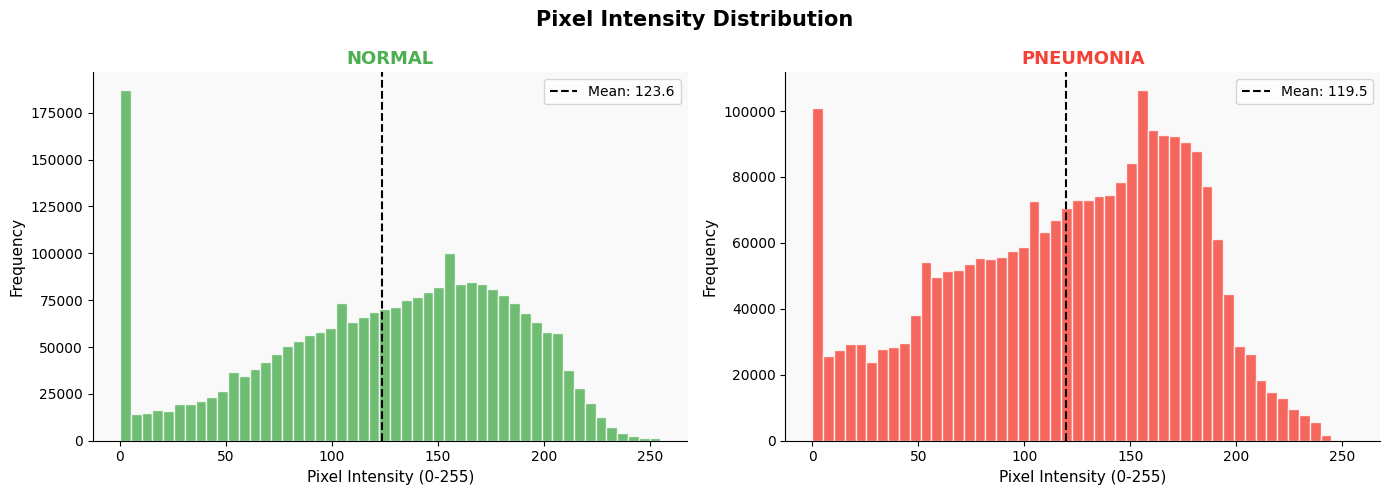

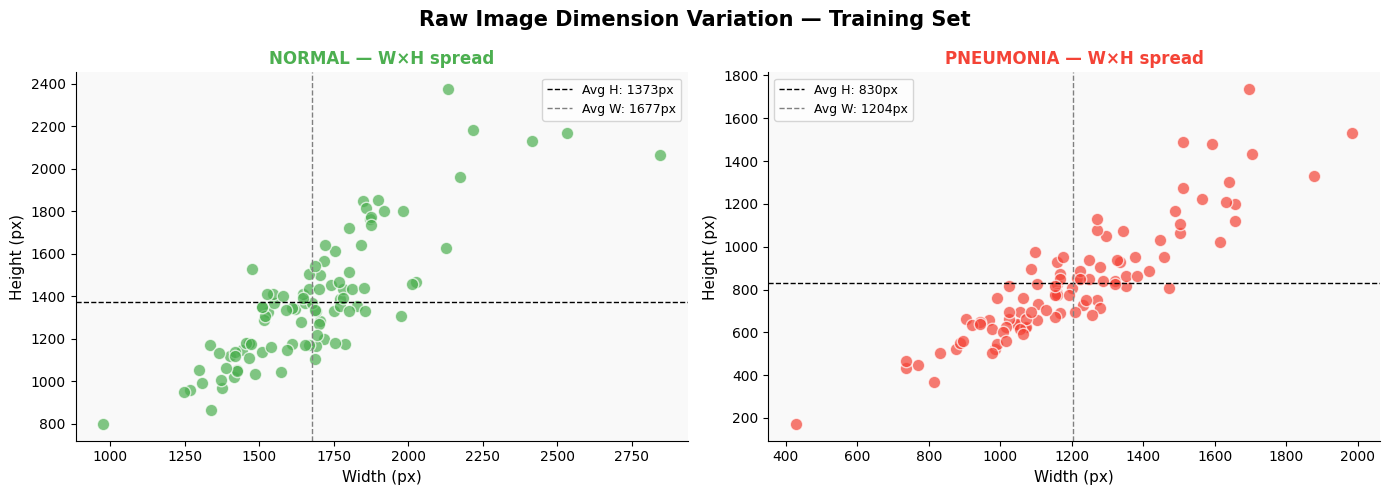

  Dataset Summary
  TRAIN  | NORMAL: 1342 | PNEUMONIA: 3876 | Total: 5218
  VAL    | NORMAL:    9 | PNEUMONIA:    9 | Total:   18
  TEST   | NORMAL:  234 | PNEUMONIA:  390 | Total:  624
  Imbalance ratio (train): 1 : 2.89
  Strategy: Class weighting + Augmentation


In [ ]:
# Plot 3: Pixel Intensity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pixel Intensity Distribution",
             fontsize=15, fontweight='bold')

for i, cls in enumerate(classes):
    path  = os.path.join(data_dir, "train", cls)
    files = [f for f in os.listdir(path)
             if f.lower().endswith(img_exts)]
    files = random.sample(files, min(50, len(files)))
    all_pixels = []
    for fname in files:
        arr = np.array(
            Image.open(os.path.join(path, fname))
                 .convert("L").resize((224, 224))
        )
        all_pixels.extend(arr.flatten().tolist())
    mean_val = np.mean(all_pixels) if all_pixels else 0
    axes[i].hist(all_pixels, bins=50, color=colors[i],
                 alpha=0.8, edgecolor='white')
    axes[i].set_title(cls, fontsize=13, fontweight='bold',
                      color=colors[i])
    axes[i].set_xlabel("Pixel Intensity (0-255)", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].axvline(mean_val, color='black', linestyle='--',
                    linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=10)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

# ── Plot 4: Image Dimensions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Raw Image Dimension Variation — Training Set",
             fontsize=15, fontweight='bold')

for i, cls in enumerate(classes):
    path  = os.path.join(data_dir, "train", cls)
    files = [f for f in os.listdir(path)
             if f.lower().endswith(img_exts)]
    files = random.sample(files, min(100, len(files)))
    widths, heights = [], []
    for fname in files:
        w, h = Image.open(os.path.join(path, fname)).size
        widths.append(w); heights.append(h)
    axes[i].scatter(widths, heights, color=colors[i],
                    alpha=0.7, edgecolor='white', s=80)
    axes[i].set_title(f"{cls} — W×H spread",
                      fontsize=12, fontweight='bold', color=colors[i])
    axes[i].set_xlabel("Width (px)", fontsize=11)
    axes[i].set_ylabel("Height (px)", fontsize=11)
    axes[i].axhline(np.mean(heights), color='black', linestyle='--',
                    linewidth=1,
                    label=f'Avg H: {np.mean(heights):.0f}px')
    axes[i].axvline(np.mean(widths), color='gray', linestyle='--',
                    linewidth=1,
                    label=f'Avg W: {np.mean(widths):.0f}px')
    axes[i].legend(fontsize=9)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────
print("=" * 55)
print("  Dataset Summary")
print("=" * 55)
for split in splits:
    n = counts[split]["NORMAL"]
    p = counts[split]["PNEUMONIA"]
    print(f"  {split.upper():<6} | NORMAL:{n:>5} | "
          f"PNEUMONIA:{p:>5} | Total:{n+p:>5}")
print("=" * 55)
ratio = (counts['train']['PNEUMONIA'] / counts['train']['NORMAL']
         if counts['train']['NORMAL'] > 0 else 0)
print(f"  Imbalance ratio (train): 1 : {ratio:.2f}")
print("  Strategy: Class weighting + Augmentation")

## **Preprocessing & Data Generators**

In [ ]:
data_dir = CONFIG["data_dir"]
img_size = CONFIG["img_size"]
batch    = CONFIG["batch_size"]
aug      = CONFIG["augmentation"]

train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = aug["rotation_range"],
    width_shift_range  = aug["width_shift_range"],
    height_shift_range = aug["height_shift_range"],
    shear_range        = aug["shear_range"],
    zoom_range         = aug["zoom_range"],
    horizontal_flip    = aug["horizontal_flip"],
    brightness_range   = aug["brightness_range"],
    fill_mode          = aug["fill_mode"],
)
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory   = os.path.join(data_dir, "train"),
    target_size = img_size,
    batch_size  = batch,
    class_mode  = "binary",
    color_mode  = "rgb",
    shuffle     = True,
    seed        = SEED,
)
val_gen = val_datagen.flow_from_directory(
    directory   = os.path.join(data_dir, "val"),
    target_size = img_size,
    batch_size  = batch,
    class_mode  = "binary",
    color_mode  = "rgb",
    shuffle     = False,
)
test_gen = test_datagen.flow_from_directory(
    directory   = os.path.join(data_dir, "test"),
    target_size = img_size,
    batch_size  = batch,
    class_mode  = "binary",
    color_mode  = "rgb",
    shuffle     = False,
)



Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# Class Weights
labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

print("  Class Weights:")
for i, cls in enumerate(CONFIG["classes"]):
    print(f"    {cls:<12} → {class_weights[i]:.4f}")



  Class Weights:
    NORMAL       → 1.9448
    PNEUMONIA    → 0.6730


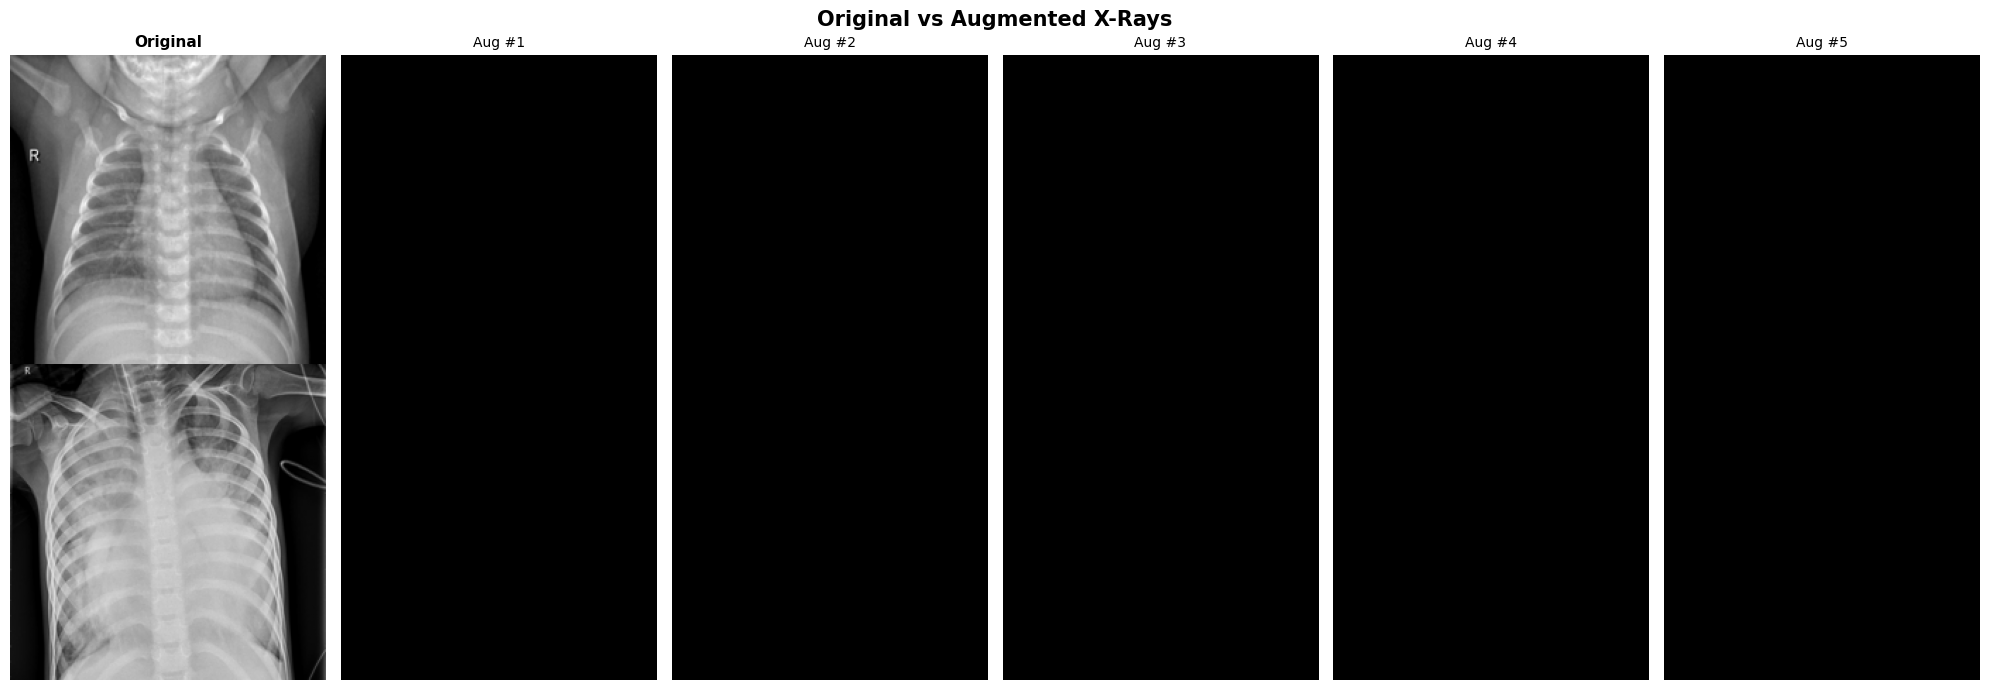

  Data Generator Summary
  Train : 5216
  Val   : 16
  Test  : 624
  Class indices : {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# Augmentation Preview
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Original vs Augmented X-Rays",
             fontsize=15, fontweight='bold')

for row, cls in enumerate(CONFIG["classes"]):
    folder = os.path.join(data_dir, "train", cls)
    fpath  = os.path.join(folder, os.listdir(folder)[0])
    orig   = np.array(
        Image.open(fpath).convert("RGB").resize(img_size)
    ) / 255.0

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title("Original" if row == 0 else "",
                            fontsize=11, fontweight='bold')
    axes[row, 0].set_ylabel(cls, fontsize=12, fontweight='bold',
                             color=CONFIG["colors"][row])
    axes[row, 0].axis('off')

    aug_gen  = ImageDataGenerator(
        rescale=1./255,
        rotation_range=aug["rotation_range"],
        width_shift_range=aug["width_shift_range"],
        height_shift_range=aug["height_shift_range"],
        shear_range=aug["shear_range"],
        zoom_range=aug["zoom_range"],
        horizontal_flip=aug["horizontal_flip"],
        brightness_range=aug["brightness_range"],
        fill_mode=aug["fill_mode"],
    )
    img_arr  = np.expand_dims(orig, axis=0)
    aug_iter = aug_gen.flow(img_arr, batch_size=1)

    for col in range(1, 6):
        aug_img = next(aug_iter)[0]
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f"Aug #{col}" if row == 0 else "",
                                  fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("=" * 55)
print("  Data Generator Summary")
print("=" * 55)
print(f"  Train : {train_gen.samples}")
print(f"  Val   : {val_gen.samples}")
print(f"  Test  : {test_gen.samples}")
print(f"  Class indices : {train_gen.class_indices}")


## **CNN From Scratch**

In [ ]:
def build_cnn_scratch(input_shape=(224, 224, 3)):

    model = models.Sequential(name="CNN_from_Scratch")

    # ── Block 1 — Low-level features (edges, textures) ───────
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.25))

    # ── Block 2 — Mid-level features ─────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.25))

    # ── Block 3 — High-level features ────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.30))

    # ── Block 4 — Complex patterns ───────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2,2))
    model.add(layers.Dropout(0.30))

    # ── Classifier Head ───────────────────────────────────────
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512,
                           kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


cnn_scratch = build_cnn_scratch(CONFIG["input_shape"])

cnn_scratch.compile(
    optimizer = Adam(learning_rate=CONFIG["learning_rate"]),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

cnn_scratch.summary()

print("\n")
print("=" * 55)
print("  CNN Architecture Breakdown")
print("=" * 55)
blocks = {
    "Block 1" : "Conv(32)  → BN → ReLU → Conv(32)  → BN → ReLU → MaxPool → Dropout(0.25)",
    "Block 2" : "Conv(64)  → BN → ReLU → Conv(64)  → BN → ReLU → MaxPool → Dropout(0.25)",
    "Block 3" : "Conv(128) → BN → ReLU → Conv(128) → BN → ReLU → MaxPool → Dropout(0.30)",
    "Block 4" : "Conv(256) → BN → ReLU → Conv(256) → BN → ReLU → MaxPool → Dropout(0.30)",
    "Head"    : "GlobalAvgPool → Dense(512) → BN → ReLU → Dropout(0.50) → Dense(1, sigmoid)",
}
for name, desc in blocks.items():
    print(f"  {name:<10} : {desc}")

print("=" * 55)
print(f"  Total Parameters : {cnn_scratch.count_params():,}")
print(f"  Input Shape      : {CONFIG['input_shape']}")
print(f"  Output           : sigmoid → 0=NORMAL, 1=PNEUMONIA")
print(f"  Loss             : Binary Crossentropy")
print(f"  Optimizer        : Adam (lr={CONFIG['learning_rate']})")
print(f"  Metrics          : Accuracy, AUC, Precision, Recall")

Model: "CNN_from_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 1,310,241 (5.00 MB)

 Trainable params: 1,307,297 (4.99 MB)

 Non-trainable params: 2,944 (11.50 KB)



  CNN Architecture Breakdown
  Block 1    : Conv(32)  → BN → ReLU → Conv(32)  → BN → ReLU → MaxPool → Dropout(0.25)
  Block 2    : Conv(64)  → BN → ReLU → Conv(64)  → BN → ReLU → MaxPool → Dropout(0.25)
  Block 3    : Conv(128) → BN → ReLU → Conv(128) → BN → ReLU → MaxPool → Dropout(0.30)
  Block 4    : Conv(256) → BN → ReLU → Conv(256) → BN → ReLU → MaxPool → Dropout(0.30)
  Head       : GlobalAvgPool → Dense(512) → BN → ReLU → Dropout(0.50) → Dense(1, sigmoid)
  Total Parameters : 1,310,241
  Input Shape      : (224, 224, 3)
  Output           : sigmoid → 0=NORMAL, 1=PNEUMONIA
  Loss             : Binary Crossentropy
  Optimizer        : Adam (lr=0.0001)
  Metrics          : Accuracy, AUC, Precision, Recall


## **Train CNN From Scratch**

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 7,
    restore_best_weights = True,
    verbose              = 1,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-7,
    verbose  = 1,
)

checkpoint = callbacks.ModelCheckpoint(
    filepath          = '/content/best_cnn_scratch.weights.h5',
    monitor           = 'val_auc',
    save_best_only    = True,
    save_weights_only = True,
    mode              = 'max',
    verbose           = 1,
)

print("=" * 55)
print("  Training CNN from Scratch")
print("=" * 55)
print(f"  Epochs     : {CONFIG['epochs_scratch']}")
print(f"  Batch size : {CONFIG['batch_size']}")
print(f"  Train size : {train_gen.samples}")
print(f"  Val size   : {val_gen.samples}")
print("=" * 55)

history_scratch = cnn_scratch.fit(
    train_gen,
    epochs          = CONFIG["epochs_scratch"],
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = [early_stop, reduce_lr, checkpoint],
    verbose         = 1,
)

cnn_scratch.load_weights('/content/best_cnn_scratch.weights.h5')
print("\n  Best weights restored.")



  Training CNN from Scratch
  Epochs     : 30
  Batch size : 32
  Train size : 5216
  Val size   : 16
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7769 - auc: 0.8711 - loss: 0.7956 - precision: 0.9445 - recall: 0.7435
Epoch 1: val_auc improved from None to 0.50000, saving model to /content/best_cnn_scratch.weights.h5

Epoch 1: finished saving model to /content/best_cnn_scratch.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.8198 - auc: 0.9071 - loss: 0.7312 - precision: 0.9593 - recall: 0.7910 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 3.1637 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8682 - auc: 0.9453 - loss: 0.6200 - precision: 0.9711 - recall: 0.8489
Epoch 2: val_auc did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.8777 - auc: 0.9504 - loss: 0.6006 - precision: 0.9734 - recall: 0.8588 - val_accuracy: 0.50

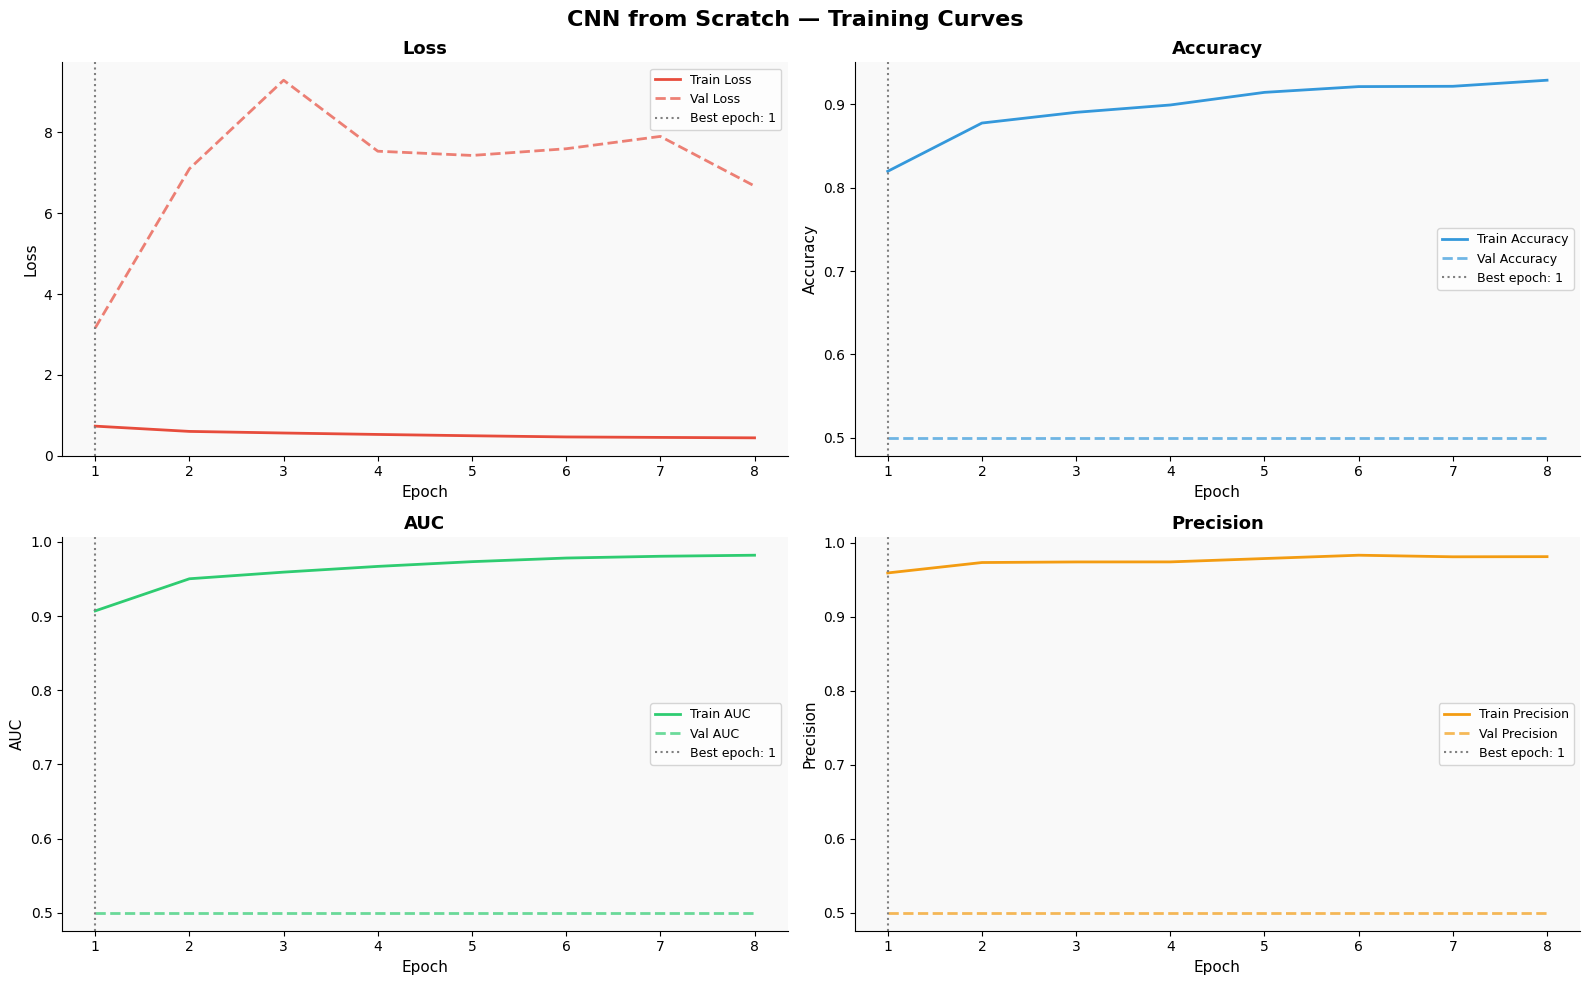



  Training Summary — CNN from Scratch
  Total epochs trained : 8
  Best epoch           : 1
  Best val loss        : 3.1637
  Best val accuracy    : 0.5000 (50.00%)
  Best val AUC         : 0.5000


In [ ]:
# Training Curves
hist   = history_scratch.history
epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("CNN from Scratch — Training Curves",
             fontsize=16, fontweight='bold')

metrics = [
    ('loss',      'val_loss',      'Loss',      '#e74c3c'),
    ('accuracy',  'val_accuracy',  'Accuracy',  '#3498db'),
    ('auc',       'val_auc',       'AUC',       '#2ecc71'),
    ('precision', 'val_precision', 'Precision', '#f39c12'),
]

for ax, (train_m, val_m, title, color) in zip(axes.flatten(), metrics):
    ax.plot(epochs, hist[train_m], color=color,
            linewidth=2, label=f'Train {title}')
    ax.plot(epochs, hist[val_m], color=color, linewidth=2,
            linestyle='--', alpha=0.7, label=f'Val {title}')
    best_ep = (np.argmin(hist[val_m]) + 1 if 'loss' in train_m
               else np.argmax(hist[val_m]) + 1)
    ax.axvline(best_ep, color='gray', linestyle=':',
               linewidth=1.5, label=f'Best epoch: {best_ep}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

best_epoch    = np.argmax(hist['val_auc']) + 1
best_val_acc  = max(hist['val_accuracy'])
best_val_auc  = max(hist['val_auc'])
best_val_loss = min(hist['val_loss'])
total_epochs  = len(hist['loss'])

print("\n")
print("=" * 55)
print("  Training Summary — CNN from Scratch")
print("=" * 55)
print(f"  Total epochs trained : {total_epochs}")
print(f"  Best epoch           : {best_epoch}")
print(f"  Best val loss        : {best_val_loss:.4f}")
print(f"  Best val accuracy    : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"  Best val AUC         : {best_val_auc:.4f}")

## **Evaluate CNN from Scratch**

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step


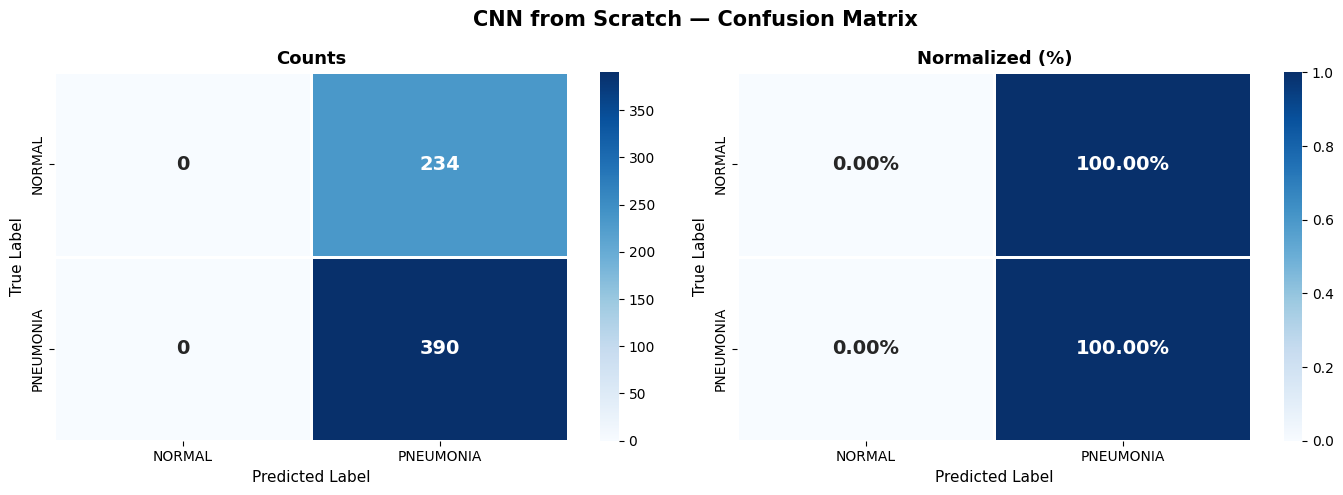

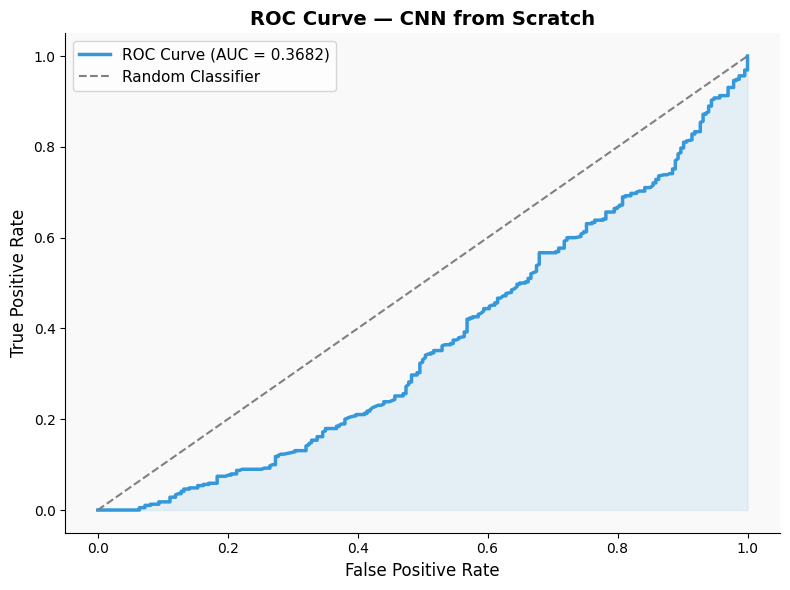

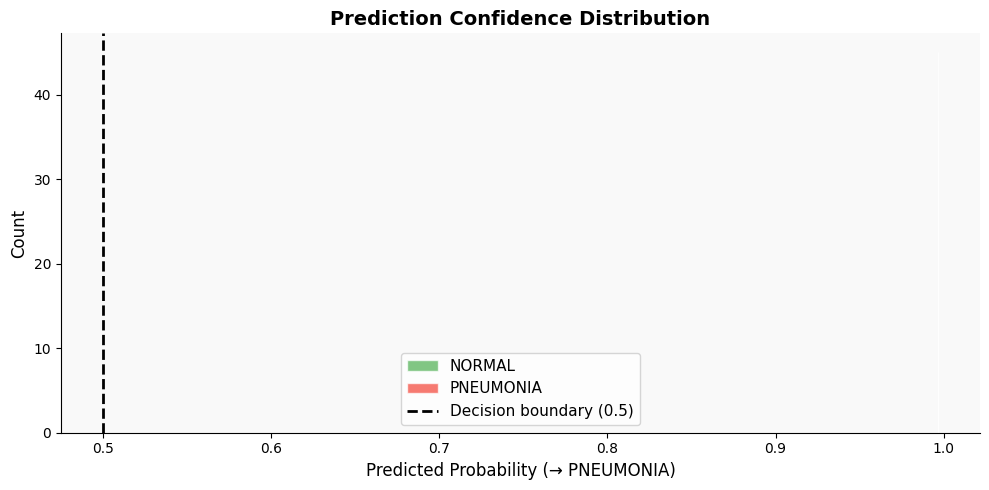

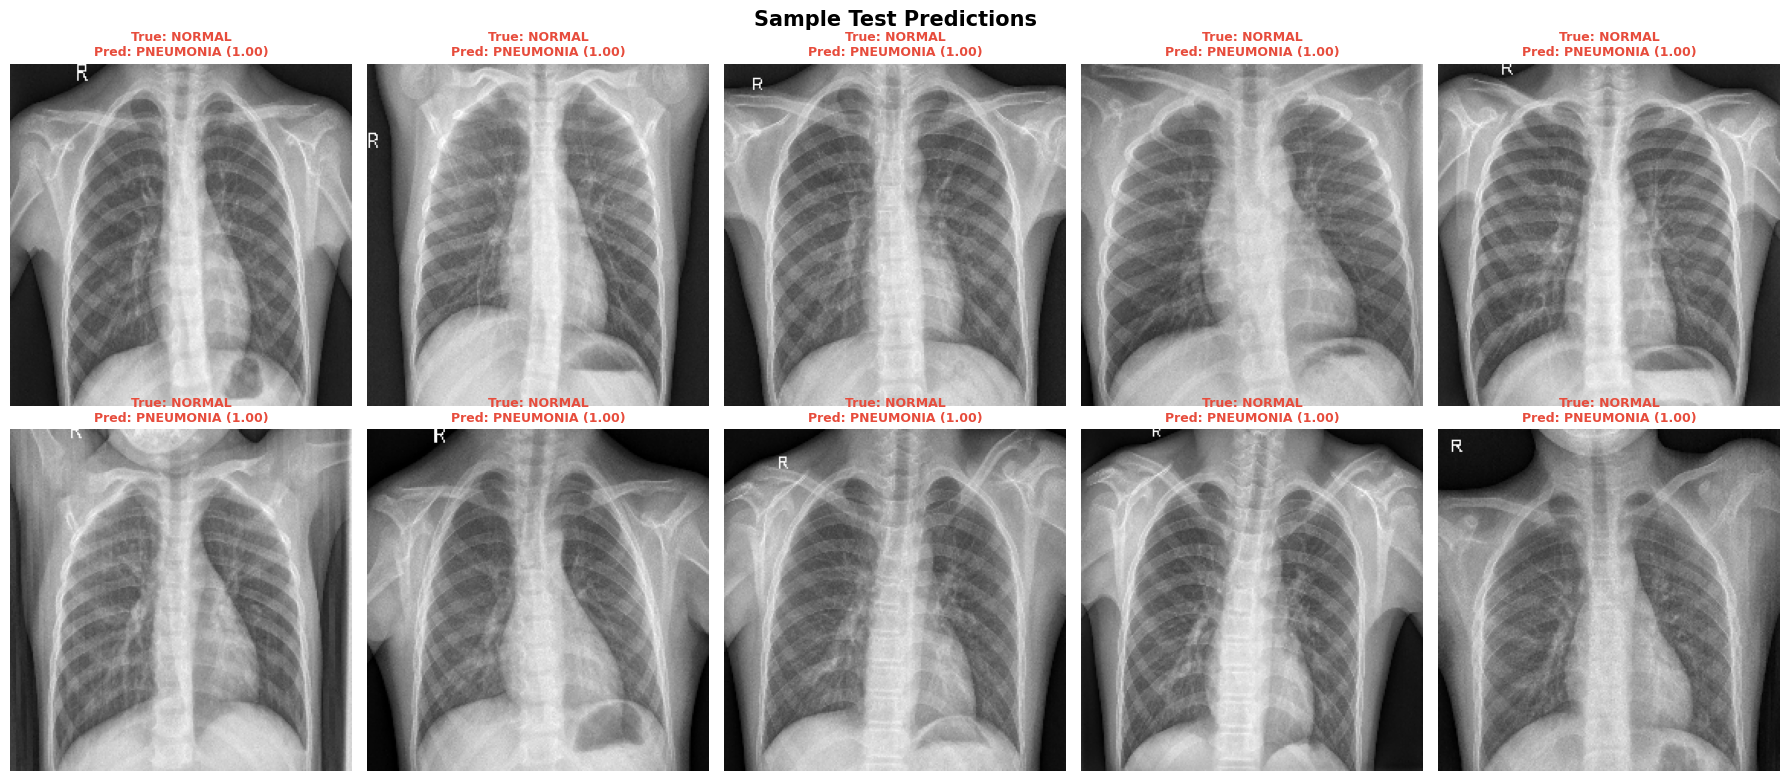

In [ ]:
from sklearn.metrics import auc

test_gen.reset()
y_prob = cnn_scratch.predict(test_gen, verbose=1).flatten()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)
labels = CONFIG["classes"]

# ── Plot 1: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN from Scratch — Confusion Matrix",
             fontsize=15, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=1, linecolor='white',
            annot_kws={"size": 14, "weight": "bold"},
            ax=axes[0])
axes[0].set_title("Counts", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=1, linecolor='white',
            annot_kws={"size": 14, "weight": "bold"},
            ax=axes[1])
axes[1].set_title("Normalized (%)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.show()

# ── Plot 2: ROC Curve ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498db', linewidth=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0,1], [0,1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax.set_title("ROC Curve — CNN from Scratch",
             fontsize=14, fontweight='bold')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

# ── Plot 3: Confidence Distribution ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_prob[y_true == 0], bins=30, alpha=0.7,
        color='#4CAF50', label='NORMAL', edgecolor='white')
ax.hist(y_prob[y_true == 1], bins=30, alpha=0.7,
        color='#F44336', label='PNEUMONIA', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--',
           linewidth=2, label='Decision boundary (0.5)')
ax.set_title("Prediction Confidence Distribution",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Predicted Probability (→ PNEUMONIA)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

# ── Plot 4: Sample Predictions Grid ──────────────────────────
test_gen.reset()
X_batch, y_batch  = next(test_gen)
probs_batch       = cnn_scratch.predict(X_batch, verbose=0).flatten()
n_show            = min(10, len(X_batch))

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Sample Test Predictions", fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i >= n_show:
        ax.axis('off')
        continue
    ax.imshow(X_batch[i])
    true_cls = labels[int(y_batch[i])]
    pred_cls = labels[int(probs_batch[i] >= 0.5)]
    conf     = (probs_batch[i] if pred_cls == "PNEUMONIA"
                else 1 - probs_batch[i])
    color    = '#2ecc71' if true_cls == pred_cls else '#e74c3c'
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.2f})",
                 fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()



In [ ]:
# Classification Report
print("\n")
print("=" * 55)
print("  Classification Report — CNN from Scratch")
print("=" * 55)
print(classification_report(y_true, y_pred,
                             target_names=labels, digits=4))

tn, fp, fn, tp = cm.ravel()
sensitivity    = tp / (tp + fn)
specificity    = tn / (tn + fp)
accuracy       = (tp + tn) / (tp + tn + fp + fn)

print("=" * 55)
print("  Key Medical Metrics")
print("=" * 55)
print(f"  Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  AUC         : {roc_auc:.4f}")
print(f"  Sensitivity : {sensitivity:.4f}  (Pneumonia Recall)")
print(f"  Specificity : {specificity:.4f}  (Normal Recall)")
print(f"  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}")
print("=" * 55)
print("  NOTE: High Sensitivity = priority in medical AI")
print("  Missing Pneumonia (FN) is more dangerous than FP")



  Classification Report — CNN from Scratch
              precision    recall  f1-score   support

      NORMAL     0.0000    0.0000    0.0000       234
   PNEUMONIA     0.6250    1.0000    0.7692       390

    accuracy                         0.6250       624
   macro avg     0.3125    0.5000    0.3846       624
weighted avg     0.3906    0.6250    0.4808       624

  Key Medical Metrics
  Accuracy    : 0.6250 (62.50%)
  AUC         : 0.3682
  Sensitivity : 1.0000  (Pneumonia Recall)
  Specificity : 0.0000  (Normal Recall)
  TP:390  TN:0  FP:234  FN:0
  NOTE: High Sensitivity = priority in medical AI
  Missing Pneumonia (FN) is more dangerous than FP


## **Transfer Learning with VGG16**

In [ ]:
def build_vgg16(input_shape=(224, 224, 3)):

    base_model = VGG16(
        weights     = 'imagenet',
        include_top = False,
        input_shape = input_shape,
    )
    base_model.trainable = False

    inputs  = keras.Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512,
                           kernel_regularizer=regularizers.l2(0.001))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Activation('relu')(x)
    x       = layers.Dropout(0.50)(x)
    x       = layers.Dense(256,
                           kernel_regularizer=regularizers.l2(0.001))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Activation('relu')(x)
    x       = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name="VGG16_Transfer")
    return model, base_model


vgg16_model, vgg16_base = build_vgg16(CONFIG["input_shape"])

# ── Phase 1: Head only ────────────────────────────────────────
vgg16_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print("=" * 55)
print("  VGG16 — Phase 1: Training Head Only")
print(f"  Frozen base layers : "
      f"{sum(not l.trainable for l in vgg16_base.layers)}")
print("=" * 55)

checkpoint_vgg16 = callbacks.ModelCheckpoint(
    filepath          = '/content/best_vgg16.weights.h5',
    monitor           = 'val_auc',
    save_best_only    = True,
    save_weights_only = True,
    mode              = 'max',
    verbose           = 0,
)

history_vgg16_p1 = vgg16_model.fit(
    train_gen,
    epochs          = 5,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = [checkpoint_vgg16,
                       callbacks.ReduceLROnPlateau(
                           monitor='val_loss', factor=0.5,
                           patience=2, verbose=1)],
    verbose         = 1,
)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  VGG16 — Phase 1: Training Head Only
  Frozen base layers : 19
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 765ms/step - accuracy: 0.8909 - auc: 0.9588 - loss: 0.9060 - precision: 0.9667 - recall: 0.8836 - val_accuracy: 0.6875 - val_auc: 0.9141 - val_loss: 1.0839 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 712ms/step - accuracy: 0.9250 - auc: 0.9779 - loss: 0.6552 - precision: 0.9773 - recall: 0.9205 - val_accuracy: 0.6875 - val_auc: 1.0000 - val_loss: 0.9073 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 729ms/step - accuracy: 0.9285 - auc: 0.9786 - loss: 0.5492 - precision: 0.9795 - recall: 0.9231 - val_accuracy: 0.8125 - val_auc: 0.9453 - val_loss: 0.7237 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 725ms/step - accuracy: 0.9331 - au

In [ ]:
# Phase 2: Fine-tune last 4 layers
vgg16_base.trainable = True
for layer in vgg16_base.layers[:-4]:
    layer.trainable = False

vgg16_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print("\n")
print("=" * 55)
print("  VGG16 — Phase 2: Fine-tuning Last 4 Layers")
print(f"  Trainable layers : "
      f"{sum(l.trainable for l in vgg16_model.layers)}")
print("=" * 55)

early_stop_vgg = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1,
)

history_vgg16_p2 = vgg16_model.fit(
    train_gen,
    epochs          = CONFIG["epochs_tl"],
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = [early_stop_vgg, checkpoint_vgg16,
                       callbacks.ReduceLROnPlateau(
                           monitor='val_loss', factor=0.5,
                           patience=3, min_lr=1e-8, verbose=1)],
    verbose         = 1,
)

vgg16_model.load_weights('/content/best_vgg16.weights.h5')
print("\n  Best VGG16 weights restored.")





  VGG16 — Phase 2: Fine-tuning Last 4 Layers
  Trainable layers : 12
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 129s 732ms/step - accuracy: 0.9450 - auc: 0.9871 - loss: 0.3699 - precision: 0.9864 - recall: 0.9388 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.3973 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 739ms/step - accuracy: 0.9536 - auc: 0.9922 - loss: 0.3373 - precision: 0.9879 - recall: 0.9492 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.4171 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 741ms/step - accuracy: 0.9611 - auc: 0.9930 - loss: 0.3260 - precision: 0.9914 - recall: 0.9559 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.3548 - val_precision: 1.0000 - val_recall: 0.8750 - learning_rate: 1.0000e-05
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 732ms/step - accuracy: 0.9647 - auc: 0.9953 - loss: 0.3115 - p

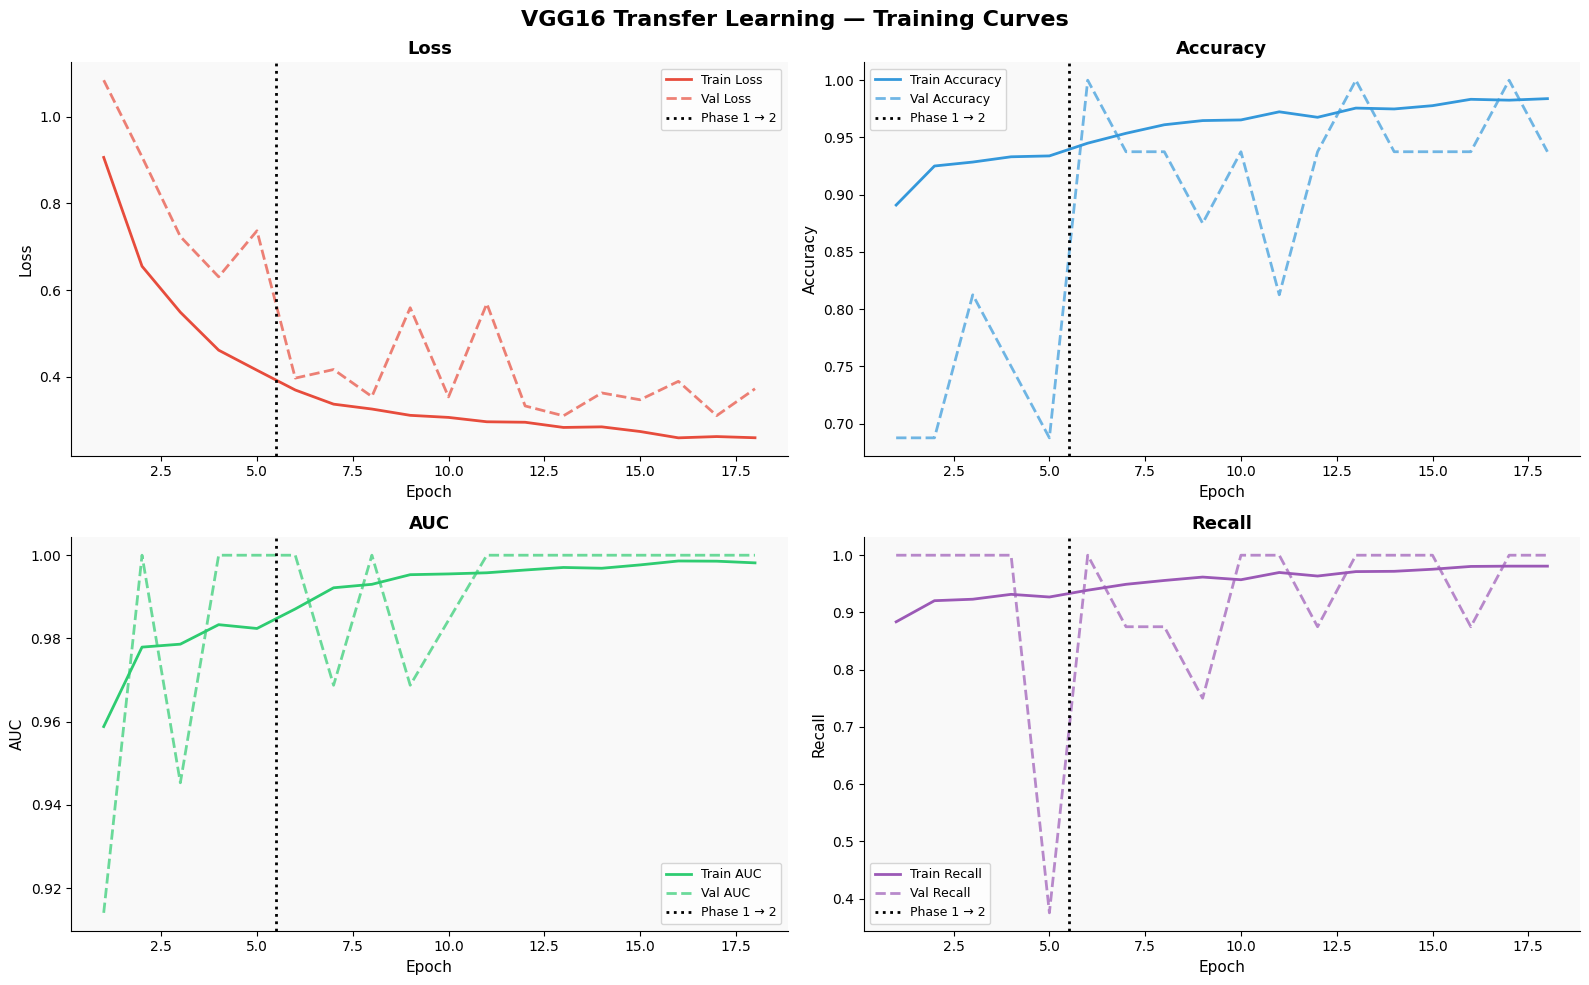



  VGG16 — Training Summary
  Phase 1 epochs    : 5   (head only,  LR=1e-3)
  Phase 2 epochs    : 13  (fine-tune, LR=1e-5)
  Best val accuracy : 1.0000
  Best val AUC      : 1.0000


In [ ]:
# Combined Training Curves
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

hist_vgg = combine_histories(history_vgg16_p1, history_vgg16_p2)
epochs_v = range(1, len(hist_vgg['loss']) + 1)
p1_end   = len(history_vgg16_p1.history['loss'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("VGG16 Transfer Learning — Training Curves",
             fontsize=16, fontweight='bold')

metrics = [
    ('loss',     'val_loss',     'Loss',     '#e74c3c'),
    ('accuracy', 'val_accuracy', 'Accuracy', '#3498db'),
    ('auc',      'val_auc',      'AUC',      '#2ecc71'),
    ('recall',   'val_recall',   'Recall',   '#9b59b6'),
]

for ax, (train_m, val_m, title, color) in zip(axes.flatten(), metrics):
    ax.plot(epochs_v, hist_vgg[train_m], color=color,
            linewidth=2, label=f'Train {title}')
    ax.plot(epochs_v, hist_vgg[val_m], color=color, linewidth=2,
            linestyle='--', alpha=0.7, label=f'Val {title}')
    ax.axvline(p1_end + 0.5, color='black', linestyle=':',
               linewidth=2, label='Phase 1 → 2')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

print("\n")
print("=" * 55)
print("  VGG16 — Training Summary")
print("=" * 55)
print(f"  Phase 1 epochs    : 5   (head only,  LR=1e-3)")
print(f"  Phase 2 epochs    : "
      f"{len(history_vgg16_p2.history['loss'])}  (fine-tune, LR=1e-5)")
print(f"  Best val accuracy : {max(hist_vgg['val_accuracy']):.4f}")
print(f"  Best val AUC      : {max(hist_vgg['val_auc']):.4f}")

## **Transfer Learning with ResNet50**

In [ ]:
def build_resnet50(input_shape=(224, 224, 3)):

    base_model = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        input_shape = input_shape,
    )
    base_model.trainable = False

    inputs  = keras.Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512,
                           kernel_regularizer=regularizers.l2(0.001))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Activation('relu')(x)
    x       = layers.Dropout(0.50)(x)
    x       = layers.Dense(256,
                           kernel_regularizer=regularizers.l2(0.001))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Activation('relu')(x)
    x       = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name="ResNet50_Transfer")
    return model, base_model


resnet_model, resnet_base = build_resnet50(CONFIG["input_shape"])



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Phase 1: Head only
resnet_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print("=" * 55)
print("  ResNet50 — Phase 1: Training Head Only")
print(f"  Frozen base layers : "
      f"{sum(not l.trainable for l in resnet_base.layers)}")
print("=" * 55)

checkpoint_resnet = callbacks.ModelCheckpoint(
    filepath          = '/content/best_resnet50.weights.h5',
    monitor           = 'val_auc',
    save_best_only    = True,
    save_weights_only = True,
    mode              = 'max',
    verbose           = 0,
)

history_resnet_p1 = resnet_model.fit(
    train_gen,
    epochs          = 5,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = [checkpoint_resnet,
                       callbacks.ReduceLROnPlateau(
                           monitor='val_loss', factor=0.5,
                           patience=2, verbose=1)],
    verbose         = 1,
)



  ResNet50 — Phase 1: Training Head Only
  Frozen base layers : 175
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 744ms/step - accuracy: 0.8229 - auc: 0.9058 - loss: 0.9458 - precision: 0.9454 - recall: 0.8083 - val_accuracy: 0.6875 - val_auc: 0.7969 - val_loss: 1.0602 - val_precision: 0.6364 - val_recall: 0.8750 - learning_rate: 0.0010
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 684ms/step - accuracy: 0.8541 - auc: 0.9373 - loss: 0.6921 - precision: 0.9571 - recall: 0.8413 - val_accuracy: 0.5000 - val_auc: 0.8203 - val_loss: 2.2611 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8780 - auc: 0.9459 - loss: 0.6081 - precision: 0.9622 - recall: 0.8696
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 696ms/step - accuracy: 0.8765 - auc: 0.9467 - loss: 0.5886 - precision: 0.9638 - recall: 0.8663 - val_accuracy: 0.6250 - val_auc: 0.8359 - val_los

In [ ]:
# Phase 2: Fine-tune last 30 layers
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer = Adam(learning_rate=1e-5),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print("\n")
print("=" * 55)
print("  ResNet50 — Phase 2: Fine-tuning Last 30 Layers")
print(f"  Trainable layers : "
      f"{sum(l.trainable for l in resnet_model.layers)}")
print("=" * 55)

early_stop_resnet = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1,
)

history_resnet_p2 = resnet_model.fit(
    train_gen,
    epochs          = CONFIG["epochs_tl"],
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = [early_stop_resnet, checkpoint_resnet,
                       callbacks.ReduceLROnPlateau(
                           monitor='val_loss', factor=0.5,
                           patience=3, min_lr=1e-8, verbose=1)],
    verbose         = 1,
)

resnet_model.load_weights('/content/best_resnet50.weights.h5')
print("\n  Best ResNet50 weights restored.")





  ResNet50 — Phase 2: Fine-tuning Last 30 Layers
  Trainable layers : 12
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 740ms/step - accuracy: 0.8466 - auc: 0.9423 - loss: 0.5543 - precision: 0.9635 - recall: 0.8248 - val_accuracy: 0.6250 - val_auc: 0.8203 - val_loss: 0.9500 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 708ms/step - accuracy: 0.8813 - auc: 0.9599 - loss: 0.4790 - precision: 0.9741 - recall: 0.8632 - val_accuracy: 0.6250 - val_auc: 0.8125 - val_loss: 1.0063 - val_precision: 1.0000 - val_recall: 0.2500 - learning_rate: 1.0000e-05
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 715ms/step - accuracy: 0.8988 - auc: 0.9655 - loss: 0.4480 - precision: 0.9750 - recall: 0.8865 - val_accuracy: 0.5625 - val_auc: 0.9219 - val_loss: 1.4757 - val_precision: 1.0000 - val_recall: 0.1250 - learning_rate: 1.0000e-05
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 715ms/step - accuracy: 0.8997 - auc: 0.9699 - loss: 0.4328

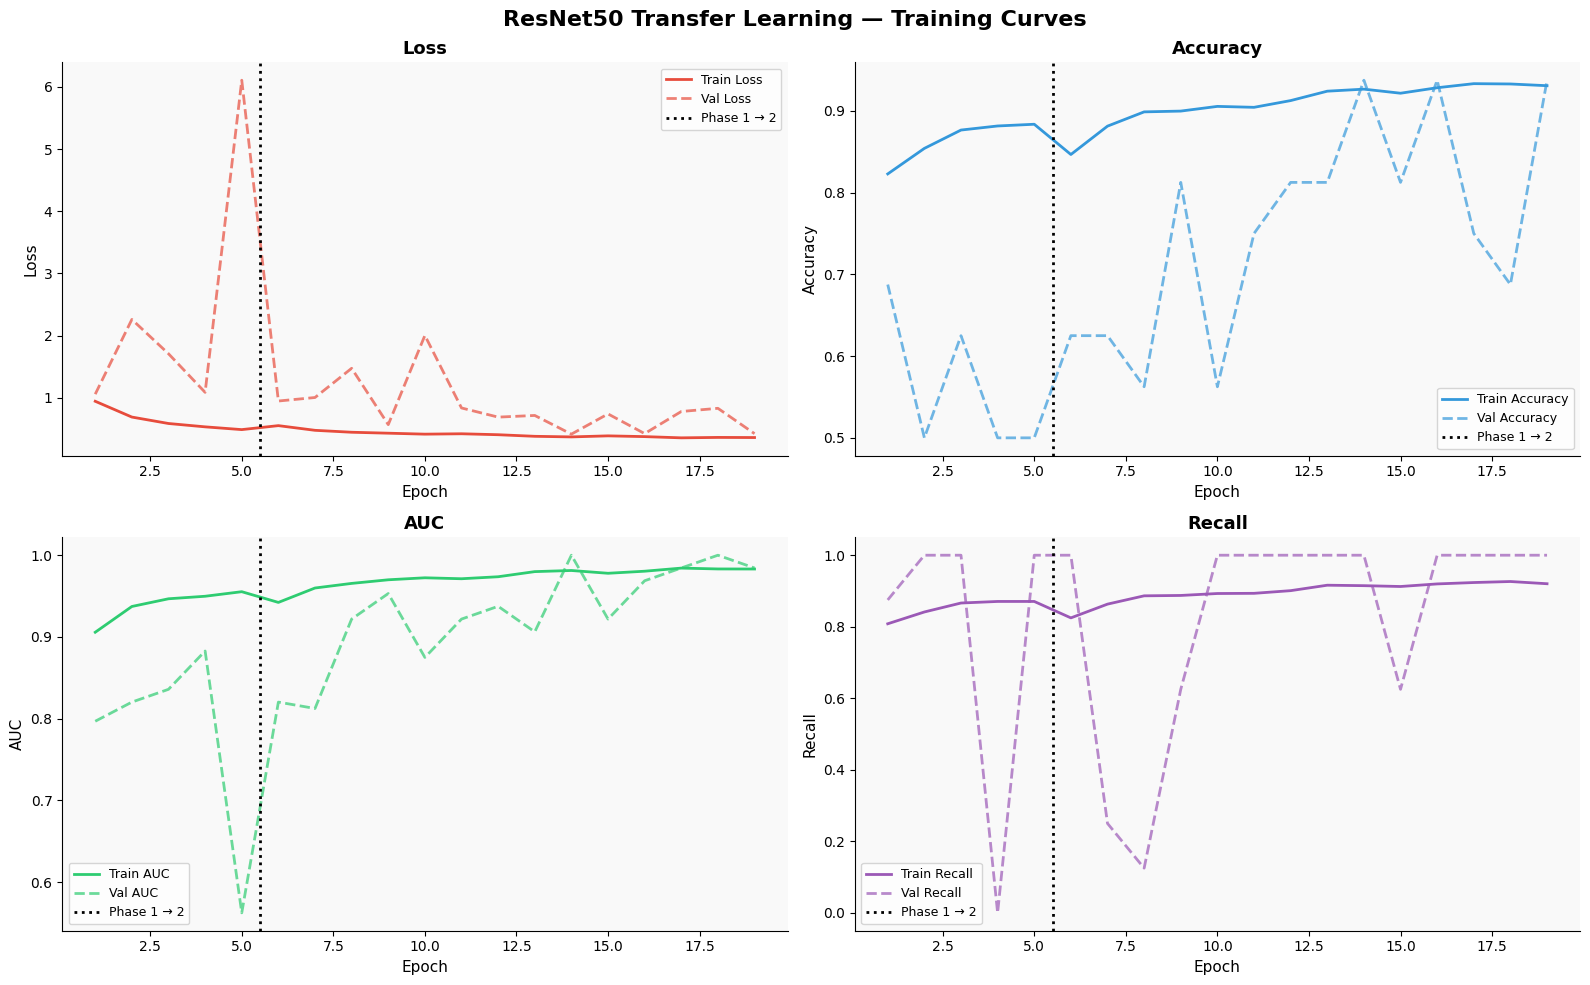



  ResNet50 — Training Summary
  Phase 1 epochs    : 5   (head only,  LR=1e-3)
  Phase 2 epochs    : 14  (fine-tune, LR=1e-5)
  Best val accuracy : 0.9375
  Best val AUC      : 1.0000


In [ ]:
# Combined Training Curves
hist_res  = combine_histories(history_resnet_p1, history_resnet_p2)
epochs_r  = range(1, len(hist_res['loss']) + 1)
p1_end_r  = len(history_resnet_p1.history['loss'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("ResNet50 Transfer Learning — Training Curves",
             fontsize=16, fontweight='bold')

for ax, (train_m, val_m, title, color) in zip(axes.flatten(), metrics):
    ax.plot(epochs_r, hist_res[train_m], color=color,
            linewidth=2, label=f'Train {title}')
    ax.plot(epochs_r, hist_res[val_m], color=color, linewidth=2,
            linestyle='--', alpha=0.7, label=f'Val {title}')
    ax.axvline(p1_end_r + 0.5, color='black', linestyle=':',
               linewidth=2, label='Phase 1 → 2')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

print("\n")
print("=" * 55)
print("  ResNet50 — Training Summary")
print("=" * 55)
print(f"  Phase 1 epochs    : 5   (head only,  LR=1e-3)")
print(f"  Phase 2 epochs    : "
      f"{len(history_resnet_p2.history['loss'])}  (fine-tune, LR=1e-5)")
print(f"  Best val accuracy : {max(hist_res['val_accuracy']):.4f}")
print(f"  Best val AUC      : {max(hist_res['val_auc']):.4f}")

## **Compare All 3 Models**

In [ ]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_prob = model.predict(generator, verbose=0).flatten()
    y_true = generator.classes
    y_pred = (y_prob >= 0.5).astype(int)

    cm             = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Model"       : model_name,
        "Accuracy"    : (tp + tn) / (tp + tn + fp + fn),
        "AUC"         : roc_auc_score(y_true, y_prob),
        "Sensitivity" : tp / (tp + fn),
        "Specificity" : tn / (tn + fp),
        "Precision"   : tp / (tp + fp),
        "F1"          : f1_score(y_true, y_pred),
        "TP"          : int(tp), "TN": int(tn),
        "FP"          : int(fp), "FN": int(fn),
        "y_prob"      : y_prob,
        "y_true"      : y_true,
        "y_pred"      : y_pred,
    }


print("  Evaluating all models on test set...")
results = {
    "CNN Scratch" : evaluate_model(cnn_scratch,  test_gen, "CNN Scratch"),
    "VGG16"       : evaluate_model(vgg16_model,  test_gen, "VGG16"),
    "ResNet50"    : evaluate_model(resnet_model, test_gen, "ResNet50"),
}

model_names  = list(results.keys())
display_cols = ["Accuracy", "AUC", "Sensitivity",
                "Specificity", "Precision", "F1"]
colors_m     = ['#3498db', '#e67e22', '#2ecc71']



  Evaluating all models on test set...


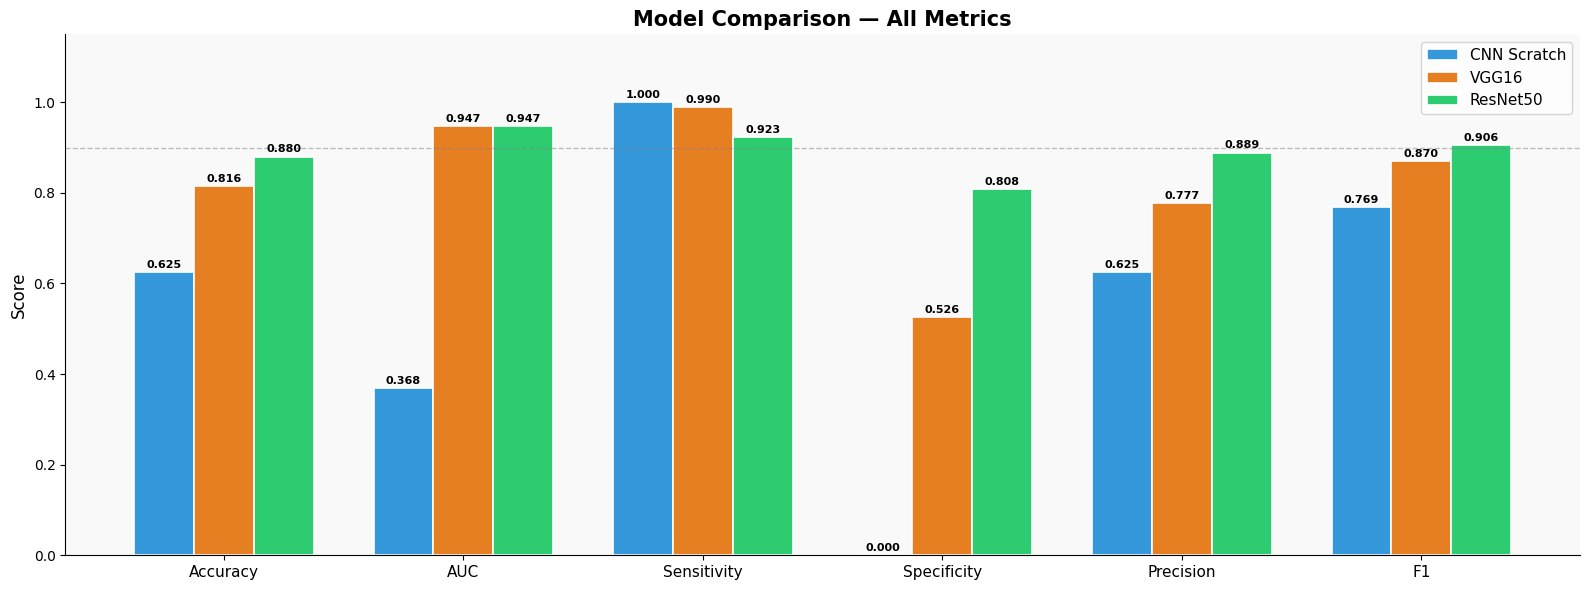

In [ ]:
# Plot 1: Grouped Bar Chart
x     = np.arange(len(display_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, color) in enumerate(zip(model_names, colors_m)):
    vals = [results[name][m] for m in display_cols]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color,
                  edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_title("Model Comparison — All Metrics",
             fontsize=15, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(display_cols, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')
ax.axhline(0.9, color='gray', linestyle='--',
           linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()



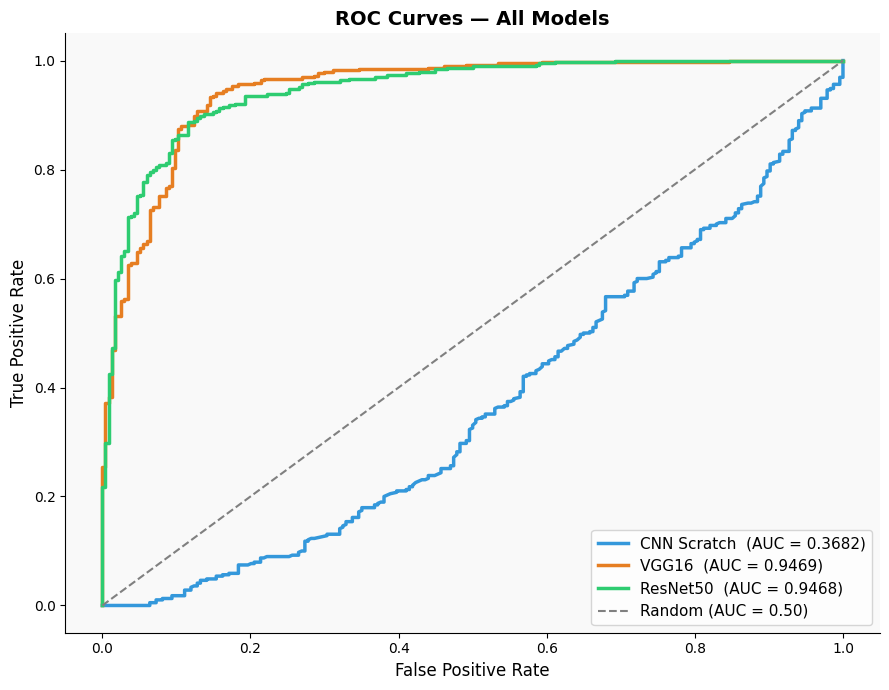

In [ ]:
# Plot 2: ROC Curves
from sklearn.metrics import auc as sklearn_auc

fig, ax = plt.subplots(figsize=(9, 7))
for (name, res), color in zip(results.items(), colors_m):
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {sklearn_auc(fpr, tpr):.4f})')

ax.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1.5,
        label='Random (AUC = 0.50)')
ax.set_title("ROC Curves — All Models",
             fontsize=14, fontweight='bold')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()



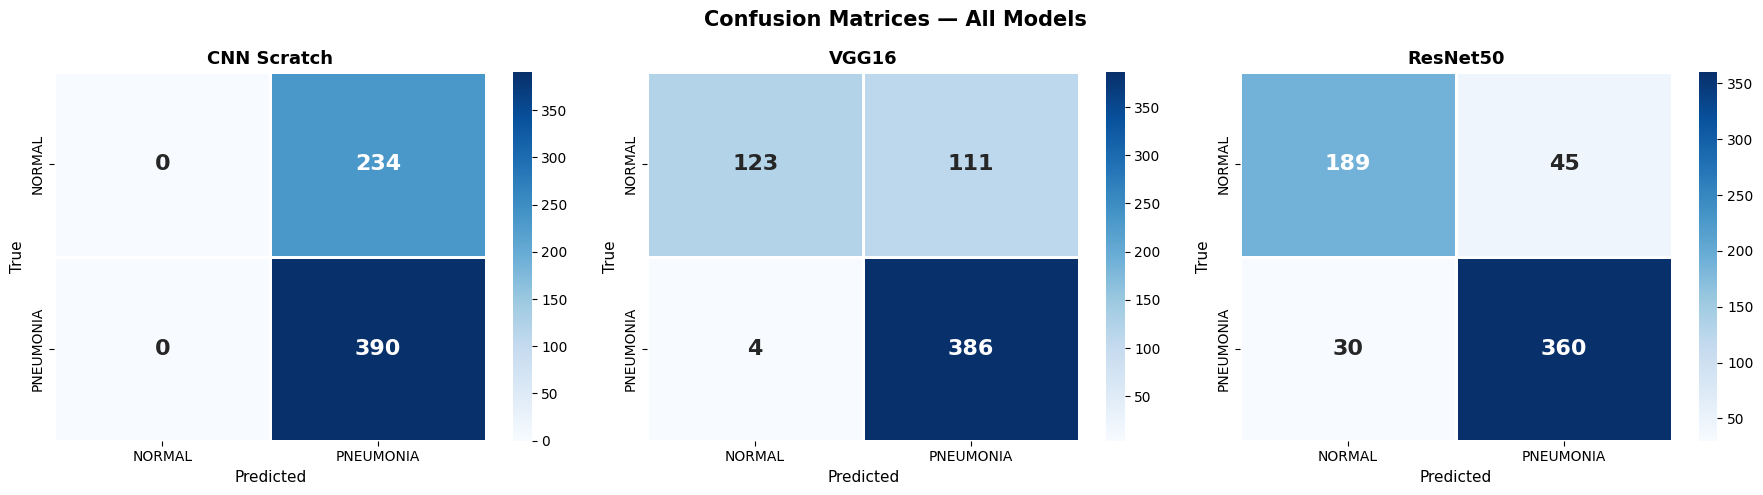

In [ ]:
# Plot 3: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models",
             fontsize=15, fontweight='bold')

for ax, (name, res), color in zip(axes, results.items(), colors_m):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CONFIG["classes"],
                yticklabels=CONFIG["classes"],
                linewidths=2, linecolor='white',
                annot_kws={"size": 16, "weight": "bold"})
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)

plt.tight_layout()
plt.show()



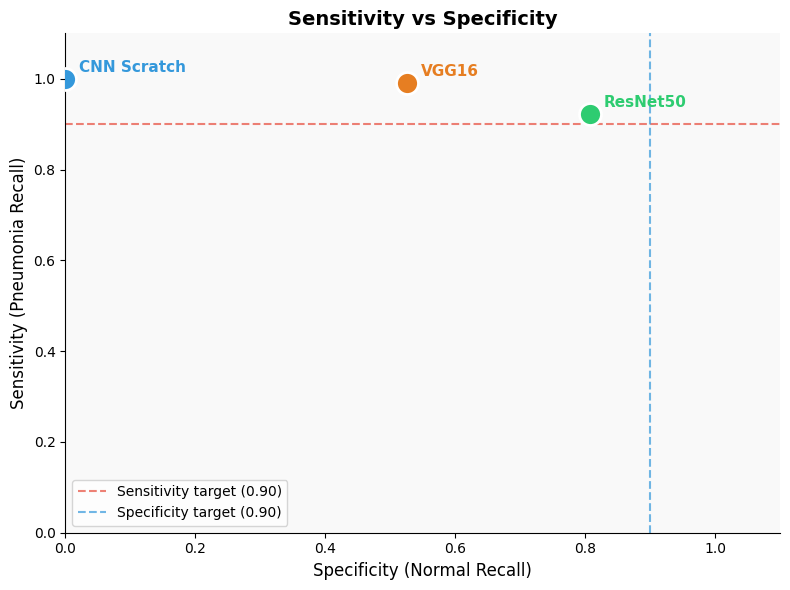

In [ ]:
# Plot 4: Sensitivity vs Specificity
sens = [results[m]["Sensitivity"] for m in model_names]
spec = [results[m]["Specificity"] for m in model_names]

fig, ax = plt.subplots(figsize=(8, 6))
for name, s, sp, color in zip(model_names, sens, spec, colors_m):
    ax.scatter(sp, s, color=color, s=250,
               zorder=5, edgecolor='white', linewidth=2)
    ax.annotate(name, (sp, s), textcoords="offset points",
                xytext=(10, 5), fontsize=11,
                fontweight='bold', color=color)

ax.axhline(0.9, color='#e74c3c', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Sensitivity target (0.90)')
ax.axvline(0.9, color='#3498db', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Specificity target (0.90)')
ax.set_title("Sensitivity vs Specificity",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Specificity (Normal Recall)", fontsize=12)
ax.set_ylabel("Sensitivity (Pneumonia Recall)", fontsize=12)
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()



In [ ]:
# Final Table
print("\n")
print("=" * 70)
print("  FINAL MODEL COMPARISON — TEST SET")
print("=" * 70)
print(f"  {'Model':<16} {'Accuracy':>9} {'AUC':>8} "
      f"{'Sensitivity':>12} {'Specificity':>12} {'F1':>8}")
print("-" * 70)

for name, res in results.items():
    print(f"  {name:<16} "
          f"{res['Accuracy']:>9.4f} "
          f"{res['AUC']:>8.4f} "
          f"{res['Sensitivity']:>12.4f} "
          f"{res['Specificity']:>12.4f} "
          f"{res['F1']:>8.4f}")

print("=" * 70)
best_by_auc  = max(results, key=lambda m: results[m]["AUC"])
best_by_sens = max(results, key=lambda m: results[m]["Sensitivity"])
print(f"\n  Best by AUC         : {best_by_auc}")
print(f"  Best by Sensitivity : {best_by_sens}  <- priority for medical AI")



  FINAL MODEL COMPARISON — TEST SET
  Model             Accuracy      AUC  Sensitivity  Specificity       F1
----------------------------------------------------------------------
  CNN Scratch         0.6250   0.3682       1.0000       0.0000   0.7692
  VGG16               0.8157   0.9469       0.9897       0.5256   0.8703
  ResNet50            0.8798   0.9468       0.9231       0.8077   0.9057

  Best by AUC         : VGG16
  Best by Sensitivity : CNN Scratch  <- priority for medical AI
